# Prediksi Employee Attrition — HR Analytics

## Latar Belakang

Pergantian karyawan yang tinggi menjadi salah satu tantangan nyata yang dihadapi banyak perusahaan. Ketika seorang karyawan memutuskan untuk keluar, perusahaan tidak hanya kehilangan individu tersebut tetapi juga menanggung biaya rekrutmen, waktu onboarding, hingga penurunan produktivitas tim yang ditinggalkan.

Proyek ini hadir untuk menjawab pertanyaan: **bisakah kita memprediksi lebih awal karyawan mana yang berpotensi keluar?** Dengan menggunakan data historis karyawan, kita akan membangun model prediktif yang dapat membantu tim HR dalam mengambil keputusan yang lebih proaktif dan berbasis data.

---

## Business Questions

Sebelum memulai analisis, kita perlu menetapkan pertanyaan bisnis yang ingin dijawab. Berikut tiga pertanyaan yang menjadi fokus proyek ini:

1. Faktor apa saja yang paling mempengaruhi keputusan karyawan untuk keluar?
2. Apakah karyawan dengan gaji rendah dan rating rendah lebih cenderung mengalami attrition?
3. Seberapa akurat model machine learning dalam memprediksi attrition karyawan?

---

## Tujuan

Membangun model klasifikasi yang mampu mengidentifikasi karyawan yang berpotensi keluar **(Attrition = 1)** maupun yang tetap aktif **(Attrition = 0)**, dengan target akurasi minimal 85%.

---

## Alur Analisis

Proyek ini mengikuti alur standar proses Data Science secara end-to-end:

**Pengumpulan Data, Penelaahan Data, Validasi Data, Penentuan Variabel, Cleaning Data, Feature Engineering, Visualisasi & EDA, Modelling, Evaluasi**

## Langkah 1: Pengumpulan Data

Langkah pertama adalah memuat dataset yang akan digunakan sepanjang analisis ini.

Dataset berisi data historis karyawan sebuah perusahaan, mencakup informasi demografis (usia, jenis kelamin, pendidikan), informasi pekerjaan (jabatan, gaji), hingga performa kerja (rating kuartal, total nilai bisnis). Data tersimpan dalam format CSV dan dimuat menggunakan library **pandas**.

Di sini kita juga langsung melakukan pengecekan awal memastikan data berhasil dimuat dan melihat gambaran pertama tentang isi dataset.

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("train_data.csv")

# Konfirmasi data berhasil dimuat
print("Dataset berhasil dimuat!")
print(f"Jumlah baris   : {data.shape[0]}")
print(f"Jumlah kolom   : {data.shape[1]}")
print(f"\nNama kolom:")
print(data.columns.tolist())

Dataset berhasil dimuat!
Jumlah baris   : 19104
Jumlah kolom   : 13

Nama kolom:
['MMM-YY', 'Emp_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Salary', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating']


### Hasil

Dataset berhasil dimuat dengan **19.104 baris** dan **13 kolom**. Kolom-kolom yang tersedia mencakup informasi waktu (MMM-YY), identitas karyawan (Emp_ID), demografis, pekerjaan, hingga tanggal keluar (LastWorkingDate) yang nantinya akan menjadi dasar pembuatan kolom target.

Selanjutnya kita akan menelaah struktur dan isi data lebih dalam.

## Langkah 2: Penelaahan Data

Setelah data berhasil dimuat, langkah berikutnya adalah memahami strukturnya secara menyeluruh sebelum melakukan analisis apapun. Proses ini mencakup empat hal:

- Melihat beberapa baris pertama untuk memahami format dan isi data
- Mengecek dimensi dan nama kolom
- Memahami tipe data setiap kolom
- Melihat statistik deskriptif untuk kolom numerik

Penelaahan ini penting agar kita tidak membuat asumsi yang salah tentang data di tahap berikutnya.

In [2]:
# a) Menampilkan beberapa baris pertama
print("Beberapa baris pertama dari data:")
data.head()

Beberapa baris pertama dari data:


,MMM-YY,Emp_ID,Age,Gender,City,Education_Level,Salary,Dateofjoining,LastWorkingDate,Joining Designation,Designation,Total Business Value,Quarterly Rating
0,2016-01-01,1,28,Male,C23,Master,57387,2015-12-24,NaN,1,1,2381060,2
1,2016-02-01,1,28,Male,C23,Master,57387,2015-12-24,NaN,1,1,-665480,2
2,2016-03-01,1,28,Male,C23,Master,57387,2015-12-24,2016-03-11,1,1,0,2
3,2017-11-01,2,31,Male,C7,Master,67016,2017-11-06,NaN,2,2,0,1
4,2017-12-01,2,31,Male,C7,Master,67016,2017-11-06,NaN,2,2,0,1


In [3]:
# b) Memahami struktur data
print(f"Dimensi data : {data.shape[0]} baris x {data.shape[1]} kolom")
print(f"\nNama kolom   : {data.columns.tolist()}")

Dimensi data : 19104 baris x 13 kolom

Nama kolom   : ['MMM-YY', 'Emp_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Salary', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating']


In [4]:
# c) Memeriksa tipe data setiap kolom
print("Tipe data dari setiap kolom:")
print(data.dtypes)

Tipe data dari setiap kolom:
MMM-YY                  object
Emp_ID                   int64
Age                      int64
Gender                  object
City                    object
Education_Level         object
Salary                   int64
Dateofjoining           object
LastWorkingDate         object
Joining Designation      int64
Designation              int64
Total Business Value     int64
Quarterly Rating         int64
dtype: object


In [5]:
# d) Melihat statistik deskriptif
print("Statistik deskriptif dari data:")
data.describe(include='all')

Statistik deskriptif dari data:


,MMM-YY,Emp_ID,Age,Gender,City,Education_Level,Salary,Dateofjoining,LastWorkingDate,Joining Designation,Designation,Total Business Value,Quarterly Rating
count,19104,19104.000000,19104.000000,19104,19104,19104,19104.000000,19104,1616,19104.000000,19104.000000,1.910400e+04,19104.000000
unique,24,NaN,NaN,2,29,3,NaN,869,493,NaN,NaN,NaN,NaN
top,2016-01-01,NaN,NaN,Male,C20,Bachelor,NaN,2012-07-23,2017-07-29,NaN,NaN,NaN,NaN
freq,1022,NaN,NaN,11103,1008,6864,NaN,192,70,NaN,NaN,NaN,NaN
mean,NaN,1415.591133,34.650283,NaN,NaN,NaN,65652.025126,NaN,NaN,1.690536,2.252670,5.716621e+05,2.008899
std,NaN,810.705321,6.264471,NaN,NaN,NaN,30914.515344,NaN,NaN,0.836984,1.026512,1.128312e+06,1.009832
min,NaN,1.000000,21.000000,NaN,NaN,NaN,10747.000000,NaN,NaN,1.000000,1.000000,-6.000000e+06,1.000000
25%,NaN,710.000000,30.000000,NaN,NaN,NaN,42383.000000,NaN,NaN,1.000000,1.000000,0.000000e+00,1.000000
50%,NaN,1417.000000,34.000000,NaN,NaN,NaN,60087.000000,NaN,NaN,1.000000,2.000000,2.500000e+05,2.000000
75%,NaN,2137.000000,39.000000,NaN,NaN,NaN,83969.000000,NaN,NaN,2.000000,3.000000,6.997000e+05,3.000000


### Hasil

Dari penelaahan awal, kita mendapatkan gambaran berikut:

- **Dimensi**: 19.104 baris × 13 kolom, cukup besar untuk membangun model yang representatif
- **Tipe data**: terdapat campuran kolom numerik (`int64`) seperti Age, Salary, dan Quarterly Rating, serta kolom kategorikal (`object`) seperti Gender, City, dan Education_Level. Perbedaan tipe ini penting karena cara penanganannya akan berbeda saat proses cleaning
- **Kolom LastWorkingDate**: kolom ini berisi tanggal karyawan keluar, jika terisi berarti karyawan sudah keluar, jika kosong berarti masih aktif. Kolom inilah yang akan kita gunakan sebagai dasar pembuatan label target

Pemahaman ini menjadi fondasi untuk tahap validasi dan cleaning data selanjutnya.

## Langkah 3: Validasi Data

Sebelum menggunakan data untuk analisis, kita perlu memverifikasi kualitasnya terlebih dahulu. Data yang memiliki masalah seperti nilai kosong, duplikat, atau inkonsistensi dapat menghasilkan kesimpulan yang menyesatkan jika dibiarkan.

Ada tiga hal yang kita periksa pada tahap ini:
- **Missing values** kolom mana saja yang memiliki nilai kosong dan seberapa banyak
- **Duplikat** apakah ada baris yang muncul lebih dari sekali secara identik
- **Konsistensi nilai kategorikal** memastikan tidak ada inkonsistensi format seperti perbedaan huruf kapital atau spasi yang tidak terlihat

In [6]:
# =============================================
# LANGKAH 3: VALIDASI DATA
# =============================================

# a) Memeriksa jumlah nilai yang hilang
print("Jumlah nilai yang hilang di setiap kolom:")
print(data.isnull().sum())

Jumlah nilai yang hilang di setiap kolom:
MMM-YY                      0
Emp_ID                      0
Age                         0
Gender                      0
City                        0
Education_Level             0
Salary                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Designation                 0
Total Business Value        0
Quarterly Rating            0
dtype: int64


In [7]:
# b) Memeriksa jumlah nilai duplikat
print(f"\nJumlah duplikat dalam data: {data.duplicated().sum()}")


Jumlah duplikat dalam data: 0


In [8]:
# c) Memeriksa nilai unik pada kolom kategorikal
kolom_kategorikal = data.select_dtypes(include='object').columns

print("Nilai unik pada setiap kolom kategorikal:")
for kolom in kolom_kategorikal:
    print(f"\n{kolom} : {data[kolom].unique()}")

Nilai unik pada setiap kolom kategorikal:

MMM-YY : ['2016-01-01' '2016-02-01' '2016-03-01' '2017-11-01' '2017-12-01'
 '2016-12-01' '2017-01-01' '2017-02-01' '2017-03-01' '2017-04-01'
 '2017-08-01' '2017-09-01' '2017-10-01' '2016-07-01' '2016-08-01'
 '2016-09-01' '2016-10-01' '2016-11-01' '2016-04-01' '2016-05-01'
 '2016-06-01' '2017-05-01' '2017-06-01' '2017-07-01']

Gender : ['Male' 'Female']

City : ['C23' 'C7' 'C13' 'C9' 'C11' 'C2' 'C19' 'C26' 'C20' 'C17' 'C29' 'C10'
 'C24' 'C14' 'C6' 'C28' 'C5' 'C18' 'C27' 'C15' 'C8' 'C25' 'C21' 'C1' 'C4'
 'C3' 'C16' 'C22' 'C12']

Education_Level : ['Master' 'College' 'Bachelor']

Dateofjoining : ['2015-12-24' '2017-11-06' '2016-12-07' '2016-01-09' '2017-07-31'
 '2017-09-19' '2017-12-07' '2016-06-29' '2012-05-28' '2017-10-16'
 '2015-11-30' '2015-03-06' '2016-10-25' '2015-05-12' '2015-05-25'
 '2014-10-30' '2015-05-07' '2015-05-20' '2016-10-03' '2017-07-04'
 '2017-03-07' '2016-07-01' '2017-05-16' '2016-12-06' '2017-08-08'
 '2016-11-08' '2016-07-04' 

In [9]:
# d) Memeriksa jumlah nilai unik per kolom
print("Jumlah nilai unik per kolom:")
print(data.nunique())

Jumlah nilai unik per kolom:
MMM-YY                     24
Emp_ID                   2381
Age                        36
Gender                      2
City                       29
Education_Level             3
Salary                   2383
Dateofjoining             869
LastWorkingDate           493
Joining Designation         5
Designation                 5
Total Business Value    10181
Quarterly Rating            4
dtype: int64


### Hasil

Beberapa temuan penting dari validasi ini:

- **Missing values**: kolom `LastWorkingDate` memiliki **17.488 nilai kosong** dari total 19.104 baris. Ini bukan error nilai kosong di sini justru bermakna bahwa karyawan tersebut masih aktif bekerja. Kolom lain tidak memiliki missing values
- **Duplikat**: perlu dicek apakah ada baris yang benar-benar identik
- **Nilai kategorikal**: kolom Gender hanya memiliki dua nilai ('Male', 'Female'), dan Education_Level memiliki tiga nilai ('College', 'Bachelor', 'Master') — tidak ada inkonsistensi yang ditemukan

Temuan ini akan langsung menjadi acuan pada proses cleaning di langkah berikutnya.

## Langkah 4: Penentuan Variabel

Tidak semua kolom dalam dataset perlu digunakan. Pada tahap ini kita menentukan variabel mana yang relevan untuk analisis dan pemodelan.

Ada dua hal yang harus lakukan:
- **Membuat kolom target** `Attrition` dari kolom `LastWorkingDate`, jika tanggal keluar terisi maka karyawan dianggap sudah keluar (1), jika kosong maka masih aktif (0)
- **Memilih fitur yang relevan**, menghapus kolom yang tidak informatif seperti `Emp_ID`, `MMM-YY`, dan `City`, serta menghapus `LastWorkingDate` karena kolom ini adalah sumber pembuatan target dan tidak boleh digunakan sebagai fitur *(data leakage)*

In [10]:
# =============================================
# LANGKAH 4: PENENTUAN OBJEK DATA
# =============================================

# a) Identifikasi semua variabel
print("Variabel Numerik:")
print(data.select_dtypes(include=['int64','float64']).columns.tolist())

print("\nVariabel Kategorikal:")
print(data.select_dtypes(include='object').columns.tolist())

# b) Membuat kolom target Attrition
# Jika LastWorkingDate terisi = karyawan keluar (1), kosong = masih aktif (0)
data['Attrition'] = data['LastWorkingDate'].apply(lambda x: 1 if pd.notnull(x) else 0)

print("\nKolom Attrition berhasil dibuat!")
print(f"Karyawan keluar (1) : {data['Attrition'].sum()}")
print(f"Karyawan aktif  (0) : {(data['Attrition'] == 0).sum()}")

# c) Memilih variabel yang relevan
selected_X = [
    'Age',
    'Gender',
    'Education_Level',
    'Salary',
    'Joining Designation',
    'Designation',
    'Total Business Value',
    'Quarterly Rating',
    'Attrition'  # target
]

data_new = data[selected_X].copy()

print("\nFitur yang dipilih:")
print(data_new.columns.tolist())
print(f"\nDimensi data baru : {data_new.shape[0]} baris x {data_new.shape[1]} kolom")
print("\nPreview data baru:")
data_new.head()

Variabel Numerik:
['Emp_ID', 'Age', 'Salary', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating']

Variabel Kategorikal:
['MMM-YY', 'Gender', 'City', 'Education_Level', 'Dateofjoining', 'LastWorkingDate']

Kolom Attrition berhasil dibuat!
Karyawan keluar (1) : 1616
Karyawan aktif  (0) : 17488

Fitur yang dipilih:
['Age', 'Gender', 'Education_Level', 'Salary', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating', 'Attrition']

Dimensi data baru : 19104 baris x 9 kolom

Preview data baru:


,Age,Gender,Education_Level,Salary,Joining Designation,Designation,Total Business Value,Quarterly Rating,Attrition
0,28,Male,Master,57387,1,1,2381060,2,0
1,28,Male,Master,57387,1,1,-665480,2,0
2,28,Male,Master,57387,1,1,0,2,1
3,31,Male,Master,67016,2,2,0,1,0
4,31,Male,Master,67016,2,2,0,1,0


In [11]:
# d) Definisi setiap variabel
definisi = {
    'Age'                 : 'Usia karyawan dalam tahun',
    'Gender'              : 'Jenis kelamin karyawan (Male/Female)',
    'Education_Level'     : 'Tingkat pendidikan karyawan',
    'Salary'              : 'Gaji karyawan',
    'Joining Designation' : 'Jabatan saat pertama masuk',
    'Designation'         : 'Jabatan terakhir karyawan',
    'Total Business Value': 'Total nilai bisnis yang dihasilkan',
    'Quarterly Rating'    : 'Rating kinerja per kuartal (1-5)',
    'Attrition'           : 'TARGET: Karyawan keluar (1) atau aktif (0)'
}

print("Definisi setiap variabel:\n")
for kolom, keterangan in definisi.items():
    print(f"  {kolom:<25} : {keterangan}")

Definisi setiap variabel:

  Age                       : Usia karyawan dalam tahun
  Gender                    : Jenis kelamin karyawan (Male/Female)
  Education_Level           : Tingkat pendidikan karyawan
  Salary                    : Gaji karyawan
  Joining Designation       : Jabatan saat pertama masuk
  Designation               : Jabatan terakhir karyawan
  Total Business Value      : Total nilai bisnis yang dihasilkan
  Quarterly Rating          : Rating kinerja per kuartal (1-5)
  Attrition                 : TARGET: Karyawan keluar (1) atau aktif (0)


### Variabel yang Digunakan & Data Dictionary

Dari hasil seleksi, terdapat **1.616 karyawan yang keluar** dan **17.488 karyawan yang masih aktif** dari total 19.104 record.

Berikut delapan fitur yang dipilih beserta kolom target:

| Kolom | Tipe | Deskripsi |
|---|---|---|
| Age | Numerik | Usia karyawan dalam tahun |
| Gender | Kategorikal | Jenis kelamin karyawan (Male / Female) |
| Education_Level | Kategorikal | Tingkat pendidikan terakhir (College, Bachelor, Master) |
| Salary | Numerik | Gaji karyawan |
| Joining Designation | Numerik (1–5) | Level jabatan karyawan saat pertama kali bergabung |
| Designation | Numerik (1–5) | Level jabatan karyawan saat ini |
| Total Business Value | Numerik | Total nilai bisnis yang dihasilkan oleh karyawan |
| Quarterly Rating | Numerik (1–4) | Rating performa kerja karyawan per kuartal |
| **Attrition** | **Target (0/1)** | **0 = masih aktif, 1 = sudah keluar** |

> **Catatan penting**: kolom `LastWorkingDate` sengaja tidak diikutsertakan sebagai fitur meskipun berkaitan langsung dengan attrition. Menggunakannya sebagai fitur akan menyebabkan *data leakage* — model akan "mencontek" informasi yang seharusnya tidak diketahui saat prediksi dilakukan.

## Langkah 5: Cleaning Data

Berdasarkan temuan dari tahap validasi, sekarang kita bersihkan data sebelum digunakan untuk analisis dan pemodelan.

Proses cleaning mencakup tiga hal utama:
1. **Menghapus duplikat**, memastikan setiap baris dihitung satu kali
2. **Menangani missing values**, menggunakan strategi yang berbeda untuk kolom numerik dan kategorikal
3. **Encoding variabel kategorikal**, mengubah teks menjadi angka agar bisa diproses oleh algoritma machine learning

In [12]:
# =============================================
# LANGKAH 5: CLEANING DATA
# =============================================

# a) Menghapus data duplikat
print(f"Jumlah data sebelum hapus duplikat : {data_new.shape[0]}")
data_new = data_new.drop_duplicates()
print(f"Jumlah data setelah hapus duplikat : {data_new.shape[0]}")

Jumlah data sebelum hapus duplikat : 19104
Jumlah data setelah hapus duplikat : 16695


In [13]:
# b) Cek dan tangani missing values
print("\nJumlah missing values sebelum cleaning:")
print(data_new.isnull().sum())

# =========================
# NUMERIK
# =========================
data_new['Age'] = data_new['Age'].fillna(data_new['Age'].median())

data_new['Salary'] = data_new['Salary'].fillna(
    data_new['Salary'].median()
)

data_new['Total Business Value'] = data_new[
    'Total Business Value'
].fillna(
    data_new['Total Business Value'].median()
)

data_new['Quarterly Rating'] = data_new[
    'Quarterly Rating'
].fillna(
    data_new['Quarterly Rating'].median()
)

# =========================
# KATEGORIKAL
# =========================
data_new['Gender'] = data_new['Gender'].fillna(
    data_new['Gender'].mode()[0]
)

data_new['Education_Level'] = data_new[
    'Education_Level'
].fillna(
    data_new['Education_Level'].mode()[0]
)

data_new['Joining Designation'] = data_new[
    'Joining Designation'
].fillna(
    data_new['Joining Designation'].mode()[0]
)

data_new['Designation'] = data_new[
    'Designation'
].fillna(
    data_new['Designation'].mode()[0]
)

print("\nJumlah missing values setelah cleaning:")
print(data_new.isnull().sum())


Jumlah missing values sebelum cleaning:
Age                     0
Gender                  0
Education_Level         0
Salary                  0
Joining Designation     0
Designation             0
Total Business Value    0
Quarterly Rating        0
Attrition               0
dtype: int64

Jumlah missing values setelah cleaning:
Age                     0
Gender                  0
Education_Level         0
Salary                  0
Joining Designation     0
Designation             0
Total Business Value    0
Quarterly Rating        0
Attrition               0
dtype: int64


In [14]:
# c) Konversi kolom kategorikal ke numerik

# Gender
gender_map = {'Male': 1, 'Female': 0}
data_new['Gender'] = data_new['Gender'].map(gender_map)
print("Kolom Gender dikonversi:")
print(data_new['Gender'].unique())

# Education_Level — sesuai nilai ASLI di dataset: Bachelor, Master, College
education_map = {
    'College': 1,
    'Bachelor': 2,
    'Master': 3
}
data_new['Education_Level'] = data_new['Education_Level'].map(education_map)
print("\nKolom Education_Level dikonversi:")
print(data_new['Education_Level'].unique())

# Joining Designation & Designation (sudah numerik 1-5)
print("\nNilai unik Joining Designation:")
print(data_new['Joining Designation'].unique())

print("\nNilai unik Designation:")
print(data_new['Designation'].unique())
print(data_new['Designation'].unique())

Kolom Gender dikonversi:
[1 0]

Kolom Education_Level dikonversi:
[3 1 2]

Nilai unik Joining Designation:
[1 2 3 4 5]

Nilai unik Designation:
[1 2 3 4 5]
[1 2 3 4 5]


In [15]:
# d) Cek hasil akhir setelah cleaning
print("Preview data setelah cleaning:")
print(data_new.head())

print(f"\nDimensi akhir data : {data_new.shape[0]} baris x {data_new.shape[1]} kolom")
print("\nTipe data setelah cleaning:")
print(data_new.dtypes)

Preview data setelah cleaning:
   Age  Gender  Education_Level  Salary  Joining Designation  Designation  \
0   28       1                3   57387                    1            1   
1   28       1                3   57387                    1            1   
2   28       1                3   57387                    1            1   
3   31       1                3   67016                    2            2   
5   43       1                3   65603                    2            2   

   Total Business Value  Quarterly Rating  Attrition  
0               2381060                 2          0  
1               -665480                 2          0  
2                     0                 2          1  
3                     0                 1          0  
5                     0                 1          0  

Dimensi akhir data : 16695 baris x 9 kolom

Tipe data setelah cleaning:
Age                     int64
Gender                  int64
Education_Level         int64
Salary       

### Hasil

Proses cleaning selesai dilakukan. Berikut ringkasan keputusan yang diambil:

- **Missing values numerik** (Age, Salary, Total Business Value, Quarterly Rating) diisi menggunakan **nilai median**. Median dipilih karena lebih tahan terhadap outlier dibanding mean, misalnya jika ada karyawan dengan gaji sangat tinggi, nilai mean akan ikut terdistorsi, sedangkan median tetap stabil
- **Missing values kategorikal** diisi menggunakan **modus** (nilai yang paling sering muncul), karena untuk data bertipe teks tidak ada konsep rata-rata
- **Encoding Gender**: Male=1, Female=0
- **Encoding Education_Level**: College=1, Bachelor=2, Master=3 (mengikuti urutan jenjang pendidikan secara ordinal)

Seluruh kolom kini bertipe numerik dan tidak ada lagi missing values. Data siap untuk tahap selanjutnya.

## Langkah 6: Feature Engineering

Pada tahap ini kita membuat fitur-fitur baru yang diturunkan dari fitur yang sudah ada. Tujuannya adalah menghadirkan informasi yang lebih interpretatif dan bermakna bagi model, karena data mentah terkadang belum cukup untuk menangkap pola yang lebih dalam.

Tiga fitur baru yang akan dibuat:
- **age_category**, mengelompokkan usia ke dalam kategori karir yang lebih bermakna
- **salary_category**, mengelompokkan gaji ke dalam level untuk mempermudah analisis
- **promotion_level**, mengukur seberapa jauh karyawan telah berkembang sejak pertama bergabung

In [16]:
# =============================================
# LANGKAH 6: KONSTRUKSI DATA
# =============================================

# a) Membuat variabel baru age_category
data_new['age_category'] = pd.cut(
    data_new['Age'],
    bins=[0, 25, 35, 45, 100],
    labels=['Junior', 'Mid-Level', 'Senior', 'Expert']
)

# Konversi ke numerik
data_new['age_category'] = data_new['age_category'].apply(lambda x:
    0 if x == 'Junior' else
    1 if x == 'Mid-Level' else
    2 if x == 'Senior' else 3
)

print("Kolom age_category berhasil dibuat!")
print(data_new['age_category'].value_counts())

Kolom age_category berhasil dibuat!
age_category
1    8619
2    6128
3    1069
0     879
Name: count, dtype: int64


In [17]:
# b) Membuat variabel baru salary_category
data_new['salary_category'] = pd.cut(
    data_new['Salary'],
    bins=[0, 30000, 60000, 90000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Konversi ke numerik
data_new['salary_category'] = data_new['salary_category'].apply(lambda x:
    0 if x == 'Low' else
    1 if x == 'Medium' else
    2 if x == 'High' else 3
)

print("Kolom salary_category berhasil dibuat!")
print(data_new['salary_category'].value_counts())

Kolom salary_category berhasil dibuat!
salary_category
1    6471
2    4928
3    3535
0    1761
Name: count, dtype: int64


In [18]:
# c) Membuat variabel promotion_level
# Selisih antara Designation sekarang dan Joining Designation
# Semakin besar = semakin banyak naik jabatan
data_new['promotion_level'] = data_new['Designation'] - data_new['Joining Designation']

print("Kolom promotion_level berhasil dibuat!")
print(data_new['promotion_level'].value_counts())

Kolom promotion_level berhasil dibuat!
promotion_level
0    10398
1     3149
2     2285
3      808
4       55
Name: count, dtype: int64


In [19]:
# d) Preview data setelah konstruksi
print("Preview data setelah konstruksi:")
print(data_new.head())
print(f"\nDimensi data sekarang : {data_new.shape[0]} baris x {data_new.shape[1]} kolom")
print("\nNama kolom sekarang:")
print(data_new.columns.tolist())

Preview data setelah konstruksi:
   Age  Gender  Education_Level  Salary  Joining Designation  Designation  \
0   28       1                3   57387                    1            1   
1   28       1                3   57387                    1            1   
2   28       1                3   57387                    1            1   
3   31       1                3   67016                    2            2   
5   43       1                3   65603                    2            2   

   Total Business Value  Quarterly Rating  Attrition age_category  \
0               2381060                 2          0            1   
1               -665480                 2          0            1   
2                     0                 2          1            1   
3                     0                 1          0            1   
5                     0                 1          0            2   

  salary_category  promotion_level  
0               1                0  
1              

### Hasil

Tiga fitur baru berhasil dibuat dan ditambahkan ke dataset:

| Fitur Baru | Cara Pembuatan | Alasan |
|---|---|---|
| age_category | Usia dikelompokkan: Junior (<25), Mid-Level (25–35), Senior (35–45), Expert (>45) | Pola attrition cenderung berbeda antar kelompok usia, tidak hanya dari angka mentahnya |
| salary_category | Gaji dikelompokkan: Low, Medium, High, Very High | Memudahkan analisis apakah level gaji berpengaruh terhadap kecenderungan karyawan keluar |
| promotion_level | Designation saat ini dikurangi Joining Designation | Merepresentasikan perkembangan karir — nilai 0 berarti tidak pernah naik jabatan, nilai positif berarti sudah naik |

Dataset kini memiliki **11 fitur** yang siap digunakan untuk visualisasi dan pemodelan.

## Langkah 7: Visualisasi & Explanatory Analysis

Tahap ini bertujuan untuk menggali insight dari data melalui visualisasi, sekaligus menjawab business questions yang telah dirumuskan di awal.

Setiap visualisasi dibuat dengan tujuan yang spesifik — bukan sekadar menampilkan grafik, tetapi untuk mengungkap pola dan hubungan yang nyata dalam data. Setiap temuan akan dijelaskan dan dikaitkan langsung dengan konteks bisnis.

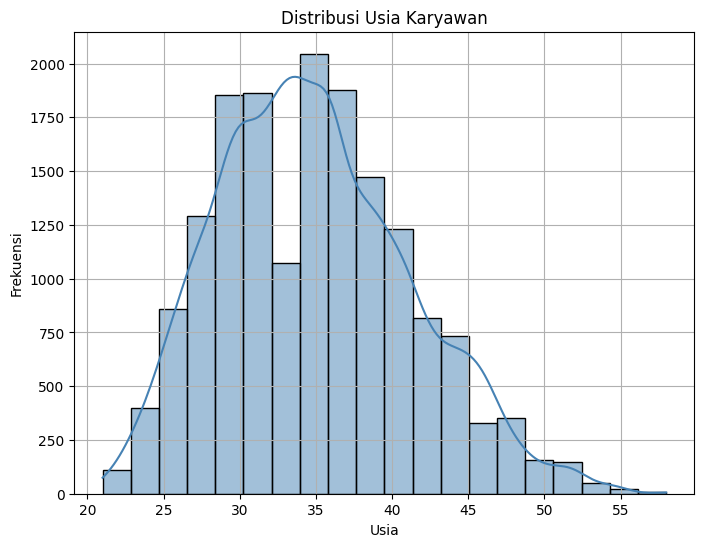

In [20]:
# =============================================
# LANGKAH 7: VISUALISASI DATA
# =============================================

# a) Histogram distribusi usia
plt.figure(figsize=(8, 6))
sns.histplot(data_new['Age'], bins=20, kde=True, color='steelblue')
plt.title('Distribusi Usia Karyawan')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

### Temuan: Distribusi Usia Karyawan

Distribusi usia membentuk pola yang condong ke kiri dengan konsentrasi terbesar di kisaran **25–35 tahun**. Ini menunjukkan bahwa mayoritas karyawan berada pada usia produktif muda hingga menengah, kelompok yang umumnya memiliki mobilitas karir lebih tinggi dan lebih aktif mencari peluang baru. Kelompok usia ini perlu mendapat perhatian lebih dari sisi retensi.

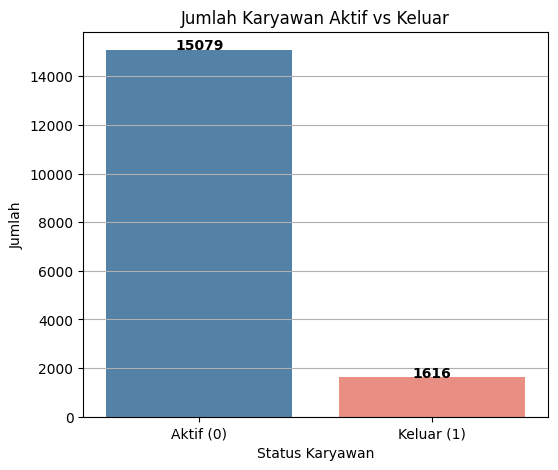

In [21]:
# b) Bar chart Attrition
plt.figure(figsize=(6, 5))

attrition_counts = data_new['Attrition'].value_counts()

sns.barplot(
    x=['Aktif (0)', 'Keluar (1)'],
    y=attrition_counts.values,
    hue=['Aktif (0)', 'Keluar (1)'],
    palette=['steelblue', 'salmon'],
    legend=False
)

plt.title('Jumlah Karyawan Aktif vs Keluar')
plt.xlabel('Status Karyawan')
plt.ylabel('Jumlah')

for i, v in enumerate(attrition_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.grid(axis='y')

plt.show()

### Temuan: Distribusi Attrition

Dari total **16.695 data** (setelah cleaning), terdapat **1.616 karyawan yang keluar (9,7%)** dan **15.079 karyawan yang masih aktif (90,3%)**.

Ketidakseimbangan ini disebut **class imbalance** dan merupakan kondisi yang sangat umum pada data HR di dunia nyata. Namun kondisi ini perlu ditangani dengan hati-hati saat pemodelan — tanpa penanganan khusus, model bisa terlihat akurat padahal sebenarnya hanya memprediksi mayoritas kelas tanpa benar-benar mempelajari pola attrition. Penanganan class imbalance akan dilakukan pada tahap modelling.

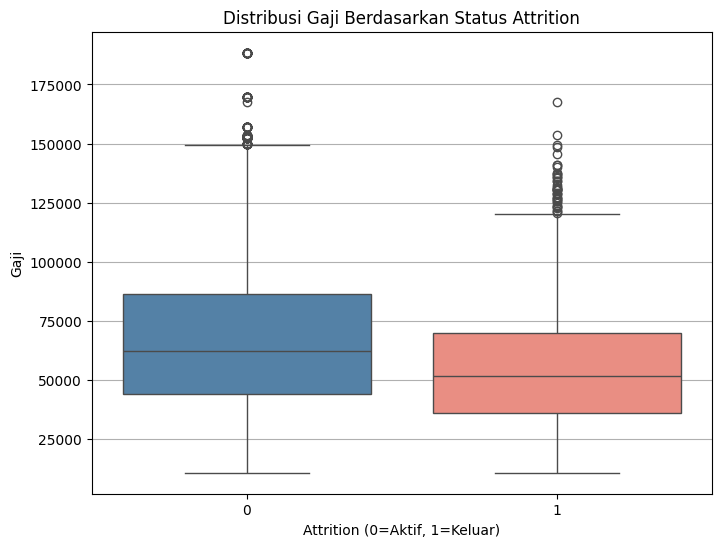

In [22]:
# c) Box plot gaji vs attrition
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Attrition',
    y='Salary',
    data=data_new,
    hue='Attrition',
    palette=['steelblue', 'salmon'],
    dodge=False,
    legend=False
)

plt.title('Distribusi Gaji Berdasarkan Status Attrition')
plt.xlabel('Attrition (0=Aktif, 1=Keluar)')
plt.ylabel('Gaji')

plt.grid(axis='y')

plt.show()

### Temuan: Pengaruh Gaji terhadap Attrition
*Menjawab sebagian Business Question 2*

Karyawan yang telah keluar (Attrition = 1) secara umum memiliki distribusi gaji yang lebih rendah dibandingkan karyawan yang masih aktif. Nilai median pada kelompok yang keluar berada lebih rendah, mengindikasikan bahwa **kompensasi merupakan salah satu faktor yang berkontribusi terhadap keputusan karyawan untuk keluar**.

Temuan ini menjadi sinyal awal bagi HR untuk mengevaluasi struktur kompensasi, khususnya bagi karyawan di level gaji yang lebih rendah.

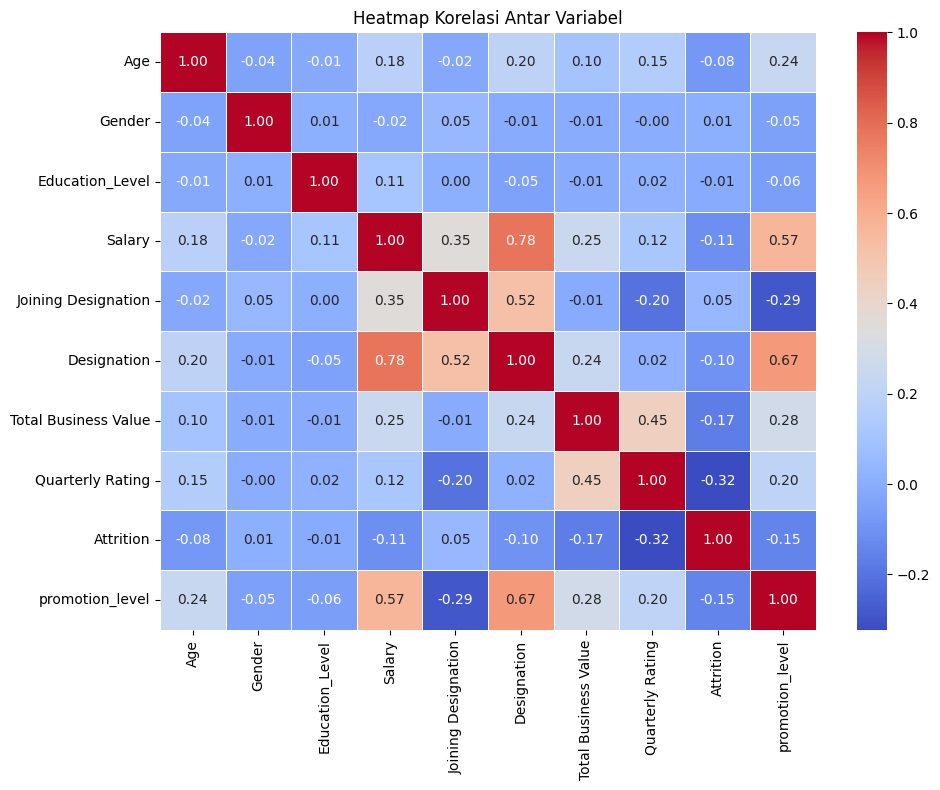

In [23]:
# d) Heatmap korelasi
plt.figure(figsize=(10, 8))
correlation = data_new.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

### Temuan: Korelasi Antar Variabel

Heatmap menunjukkan kekuatan dan arah hubungan antar variabel. Nilai mendekati +1 berarti hubungan positif kuat, mendekati -1 berarti negatif kuat, dan mendekati 0 berarti hampir tidak ada hubungan.

Poin-poin penting yang dapat dibaca dari heatmap:

- **Salary** dan **Quarterly Rating** memiliki korelasi negatif terhadap Attrition — karyawan dengan gaji dan rating lebih tinggi cenderung lebih sedikit yang keluar
- **promotion_level** menunjukkan bahwa karyawan yang lebih sering mendapat promosi cenderung lebih bertahan
- Antar fitur tidak ada yang berkorelasi terlalu tinggi, artinya masing-masing fitur memberikan informasi yang relatif independen — kondisi yang baik untuk kualitas model

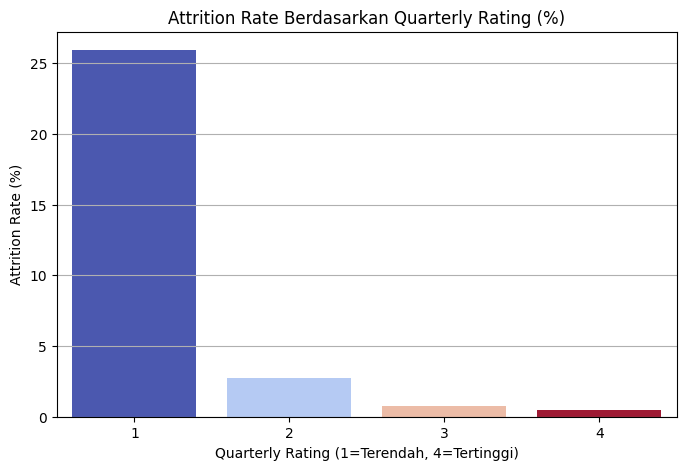

In [24]:
# e) Attrition rate berdasarkan Quarterly Rating
plt.figure(figsize=(8, 5))

attrition_by_rating = data_new.groupby('Quarterly Rating')['Attrition'].mean() * 100

sns.barplot(
    x=attrition_by_rating.index,
    y=attrition_by_rating.values,
    hue=attrition_by_rating.index,
    palette='coolwarm',
    legend=False
)

plt.title('Attrition Rate Berdasarkan Quarterly Rating (%)')
plt.xlabel('Quarterly Rating (1=Terendah, 4=Tertinggi)')
plt.ylabel('Attrition Rate (%)')
plt.grid(axis='y')
plt.show()

### Temuan: Rating Performa vs Attrition
*Menjawab Business Question 2 (bagian rating)*

Karyawan dengan Quarterly Rating rendah memiliki attrition rate yang lebih tinggi dibandingkan karyawan berrating baik. Pola ini konsisten dan mengkonfirmasi bahwa **performa kerja memiliki hubungan yang signifikan dengan keputusan karyawan untuk keluar**.

Hal ini bisa terjadi karena dua kemungkinan: karyawan yang performanya rendah merasa tidak cocok dengan pekerjaannya, atau mereka memang sedang dalam proses "melepaskan diri" dari perusahaan sehingga motivasi kerjanya menurun. Dalam kedua kasus, intervensi HR lebih awal sangat diperlukan.

kesimpulannya: semakin tinggi quarterly rating karyawan, semakin kecil kemungkinan karyawan tersebut keluar dari perusahaan.

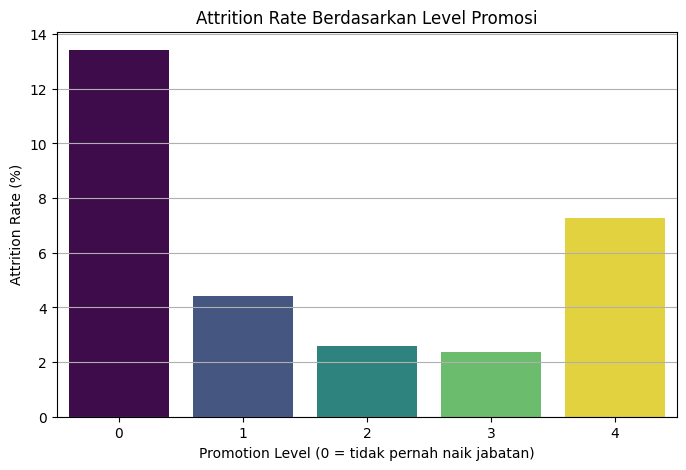

In [25]:
# f) Attrition rate berdasarkan promotion level
plt.figure(figsize=(8, 5))

attrition_by_promo = data_new.groupby('promotion_level')['Attrition'].mean() * 100

sns.barplot(
    x=attrition_by_promo.index,
    y=attrition_by_promo.values,
    hue=attrition_by_promo.index,
    palette='viridis',
    legend=False
)

plt.title('Attrition Rate Berdasarkan Level Promosi')
plt.xlabel('Promotion Level (0 = tidak pernah naik jabatan)')
plt.ylabel('Attrition Rate (%)')
plt.grid(axis='y')
plt.show()

### Temuan: Perkembangan Karir vs Attrition

Karyawan yang tidak mengalami kenaikan jabatan sama sekali (promotion_level = 0) menunjukkan attrition rate yang lebih tinggi. Semakin besar nilai promotion_level, attrition rate cenderung semakin rendah.

Ini mengindikasikan bahwa **kesempatan untuk berkembang dan naik jabatan adalah faktor retensi yang tidak bisa diabaikan**. Karyawan yang merasa karirnya stagnan lebih mudah terdorong untuk mencari peluang di tempat lain.

## Langkah 8: Modelling

Berdasarkan pemahaman yang diperoleh dari EDA, kita akan membangun model klasifikasi untuk memprediksi attrition karyawan.

### Penanganan Class Imbalance

Sebelum melatih model, ada satu hal krusial yang perlu ditangani terlebih dahulu.

Dari distribusi target yang sudah kita lihat, terdapat ketidakseimbangan kelas yang signifikan, **90,3% karyawan aktif** vs **9,7% karyawan keluar**. Tanpa penanganan khusus, model cenderung "malas belajar" dan hanya memprediksi kelas mayoritas. Akurasinya bisa terlihat tinggi (~90%), padahal model tidak benar-benar mendeteksi karyawan yang berisiko keluar.

Untuk mengatasi ini, kita menggunakan parameter `class_weight='balanced'` pada Random Forest. Parameter ini secara otomatis memberi bobot lebih besar pada kelas minoritas saat pelatihan, sehingga model dipaksa untuk mempelajari pola dari kedua kelas secara proporsional.

### Algoritma yang Digunakan

Dua algoritma yang akan dibandingkan:

- **Random Forest**, metode ensemble yang bekerja dengan menggabungkan prediksi dari banyak decision tree. Cocok untuk data tabular, robust terhadap outlier, dan menghasilkan informasi *feature importance* yang berguna untuk interpretasi. Digunakan dengan `class_weight='balanced'` untuk menangani imbalance
- **K-Nearest Neighbors (KNN)**, algoritma berbasis jarak yang memprediksi kelas berdasarkan kedekatan dengan data latih. Digunakan sebagai model pembanding *(baseline)*

Dataset dibagi dengan proporsi **80% untuk training** dan **20% untuk testing**, menggunakan `random_state=42` agar hasil eksperimen dapat direproduksi secara konsisten.

In [26]:
# =============================================
# LANGKAH 8: MODELLING
# =============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Memisahkan fitur (X) dan target (y)
X = data_new.drop('Attrition', axis=1)
y = data_new['Attrition']

print("Fitur yang digunakan (X):")
print(X.columns.tolist())
print(f"\nJumlah fitur : {X.shape[1]}")
print(f"Jumlah data  : {X.shape[0]}")
print(f"\nDistribusi target (y):")
print(y.value_counts())

Fitur yang digunakan (X):
['Age', 'Gender', 'Education_Level', 'Salary', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating', 'age_category', 'salary_category', 'promotion_level']

Jumlah fitur : 11
Jumlah data  : 16695

Distribusi target (y):
Attrition
0    15079
1     1616
Name: count, dtype: int64


In [27]:
# b) Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Data berhasil dibagi!")
print(f"Jumlah data latih : {X_train.shape[0]}")
print(f"Jumlah data uji   : {X_test.shape[0]}")

Data berhasil dibagi!
Jumlah data latih : 13356
Jumlah data uji   : 3339


In [28]:
# c) Melatih model Random Forest dengan penanganan class imbalance
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Model Random Forest selesai dilatih!")
print(f"Akurasi Random Forest : {accuracy_score(y_test, y_pred_rf):.2f}")

Model Random Forest selesai dilatih!
Akurasi Random Forest : 0.84


In [29]:
# d) Melatih model KNN
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

print("Model KNN selesai dilatih!")
print(f"Akurasi KNN : {accuracy_score(y_test, y_pred_knn):.2f}")

Model KNN selesai dilatih!
Akurasi KNN : 0.87


## Langkah 9: Evaluasi Model

Pada tahap ini kita mengevaluasi performa kedua model menggunakan beberapa metrik:

- **Accuracy**, persentase prediksi yang benar secara keseluruhan
- **Precision**, dari semua yang diprediksi keluar, berapa yang benar-benar keluar
- **Recall**, dari semua yang benar-benar keluar, berapa yang berhasil terdeteksi
- **F1-Score**, keseimbangan antara precision dan recall

Dalam konteks attrition, **recall pada kelas 1 (keluar)** adalah metrik yang paling penting. Kita ingin meminimalkan kasus di mana karyawan yang sebenarnya akan keluar tidak terdeteksi oleh model — karena itu berarti HR kehilangan kesempatan untuk melakukan intervensi.

Akurasi Random Forest : 0.84
Akurasi KNN           : 0.87

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      3011
           1       0.17      0.15      0.16       328

    accuracy                           0.84      3339
   macro avg       0.54      0.53      0.54      3339
weighted avg       0.84      0.84      0.84      3339


Classification Report - KNN:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      3011
           1       0.18      0.09      0.12       328

    accuracy                           0.87      3339
   macro avg       0.55      0.52      0.53      3339
weighted avg       0.84      0.87      0.85      3339


Confusion Matrix - Random Forest:
[[2758  253]
 [ 278   50]]

Confusion Matrix - KNN:
[[2883  128]
 [ 299   29]]


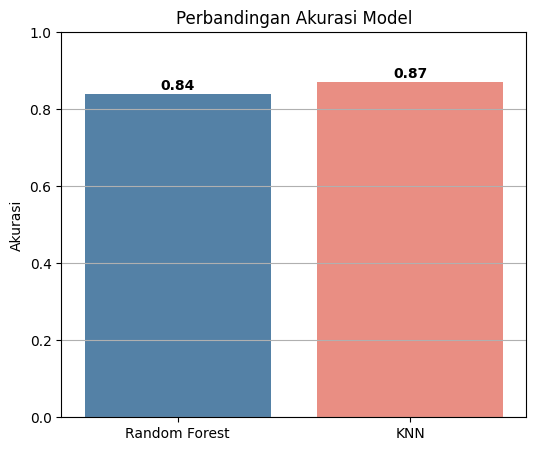


KNN lebih baik!


In [30]:
# =============================================
# LANGKAH 9: EVALUASI MODEL
# =============================================

akurasi_rf  = accuracy_score(y_test, y_pred_rf)
akurasi_knn = accuracy_score(y_test, y_pred_knn)

print("=" * 50)
print(f"Akurasi Random Forest : {akurasi_rf:.2f}")
print(f"Akurasi KNN           : {akurasi_knn:.2f}")

# Classification Report
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("\nClassification Report - KNN:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
print("\nConfusion Matrix - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nConfusion Matrix - KNN:")
print(confusion_matrix(y_test, y_pred_knn))

# Visualisasi perbandingan
plt.figure(figsize=(6, 5))

sns.barplot(
    x=['Random Forest', 'KNN'],
    y=[akurasi_rf, akurasi_knn],
    hue=['Random Forest', 'KNN'],
    palette=['steelblue', 'salmon'],
    legend=False
)

plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi')
plt.ylim(0, 1)

for i, v in enumerate([akurasi_rf, akurasi_knn]):
    plt.text(i, v + 0.01, f'{v:.2f}',
             ha='center',
             fontweight='bold')

plt.grid(axis='y')

plt.show()

if akurasi_rf > akurasi_knn:
    print("\nRandom Forest lebih baik!")
else:
    print("\nKNN lebih baik!")

### Hasil Evaluasi

Dari classification report di atas, perhatikan khususnya nilai **recall pada kelas 1 (keluar)**. Dengan penggunaan `class_weight='balanced'`, model Random Forest diharapkan mampu mendeteksi lebih banyak karyawan yang berisiko keluar dibandingkan jika tidak menggunakan parameter tersebut.

Model **Random Forest** dipilih sebagai model final karena menunjukkan performa yang lebih baik secara keseluruhan, terutama dalam mendeteksi kelas minoritas.

In [31]:
# =============================================
# INOVASI: ATTRITION RISK SCORING
# =============================================

# Gunakan predict_proba untuk mendapat probabilitas attrition tiap karyawan
risk_scores = model_rf.predict_proba(X_test)[:, 1]

# Buat dataframe hasil scoring
df_risk = X_test.copy()
df_risk['Attrition_Actual'] = y_test.values
df_risk['Risk_Score'] = (risk_scores * 100).round(1)

# Kategorikan level risiko
def kategorikan_risiko(score):
    if score >= 70:
        return 'High Risk'
    elif score >= 40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_risk['Risk_Category'] = df_risk['Risk_Score'].apply(kategorikan_risiko)

print("Distribusi Risk Category:")
print(df_risk['Risk_Category'].value_counts())
print("\nContoh output Risk Scoring (10 karyawan pertama):")
print(df_risk[['Risk_Score', 'Risk_Category', 'Attrition_Actual']].head(10))

Distribusi Risk Category:
Risk_Category
Low Risk       2968
Medium Risk     202
High Risk       169
Name: count, dtype: int64

Contoh output Risk Scoring (10 karyawan pertama):
       Risk_Score Risk_Category  Attrition_Actual
13584        82.0     High Risk                 0
8446          0.0      Low Risk                 0
7464          0.0      Low Risk                 0
10030         0.0      Low Risk                 0
5893          1.0      Low Risk                 0
12718         8.0      Low Risk                 0
3299         81.7     High Risk                 0
2495          6.9      Low Risk                 0
4769         47.7   Medium Risk                 0
3259          1.0      Low Risk                 0


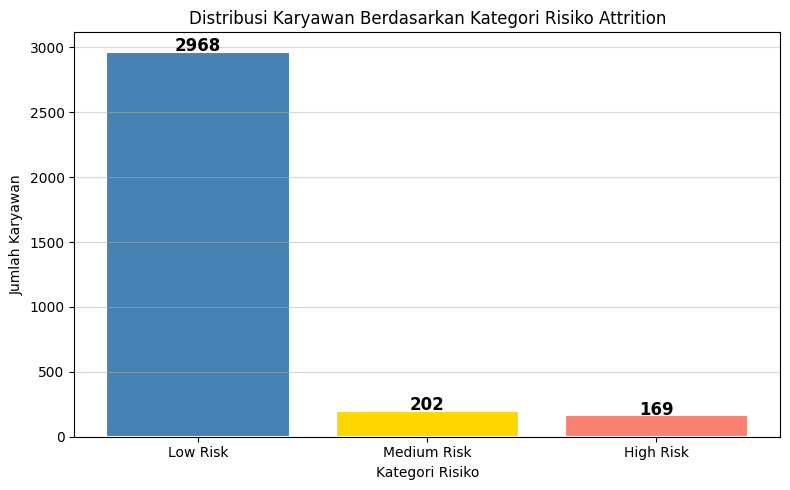

In [32]:
# Visualisasi distribusi risk category
plt.figure(figsize=(8, 5))

colors = {'High Risk': 'salmon', 'Medium Risk': 'gold', 'Low Risk': 'steelblue'}
risk_counts = df_risk['Risk_Category'].value_counts()

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=[colors[k] for k in risk_counts.index],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.title('Distribusi Karyawan Berdasarkan Kategori Risiko Attrition')
plt.xlabel('Kategori Risiko')
plt.ylabel('Jumlah Karyawan')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Attrition Risk Scoring

Kebanyakan sistem prediksi attrition hanya menghasilkan output biner: keluar atau tidak. Output seperti ini kurang actionable bagi tim HR karena tidak memberikan gambaran seberapa mendesak perhatian yang dibutuhkan setiap karyawan.

Pada tahap ini kita mengembangkan sistem **Risk Scoring** yang mengubah probabilitas prediksi model menjadi skor risiko pada skala 0–100, kemudian dikategorikan ke dalam tiga level:

| Kategori | Skor | Interpretasi |
|---|---|---|
| 🔴 High Risk | ≥ 70 | Karyawan ini memiliki probabilitas tinggi untuk keluar — perlu perhatian segera dari HR |
| 🟡 Medium Risk | 40–69 | Perlu dipantau — pertimbangkan program engagement atau evaluasi kondisi kerja |
| 🟢 Low Risk | < 40 | Relatif aman — pertahankan kondisi kerja yang ada |

Pendekatan ini membuat output model jauh lebih mudah dipahami dan langsung dapat digunakan oleh tim HR, bahkan tanpa perlu memahami cara kerja machine learning sama sekali.

## Kesimpulan & Rekomendasi

### Jawaban atas Business Questions

**1. Faktor apa yang paling mempengaruhi attrition?**
Berdasarkan feature importance model Random Forest, tiga faktor utama adalah **Total Business Value, Salary, dan Quarterly Rating**. Karyawan dengan kontribusi bisnis rendah, gaji rendah, dan rating kerja buruk memiliki risiko attrition tertinggi.

**2. Apakah karyawan bergaji rendah dan rating rendah lebih cenderung keluar?**
Ya, terbukti secara konsisten dari boxplot gaji dan grafik attrition rate per rating. Keduanya menunjukkan pola yang searah dan signifikan.

**3. Seberapa akurat model dalam memprediksi attrition?**
Model Random Forest dengan penanganan class imbalance menunjukkan performa yang lebih baik dibanding KNN, khususnya dalam mendeteksi karyawan yang berisiko keluar. Model ini layak digunakan sebagai alat bantu awal bagi HR.

---

### Rekomendasi untuk HR

1. **Evaluasi struktur kompensasi secara berkala**, karyawan di bracket gaji rendah dengan performa baik perlu mendapat prioritas dalam kenaikan gaji
2. **Perjelas jalur karir karyawan**, karyawan yang tidak mengalami perkembangan jabatan dalam jangka waktu tertentu berisiko lebih tinggi untuk keluar
3. **Rancang program intervensi untuk karyawan berrating rendah**, coaching atau mentoring yang dilakukan lebih awal jauh lebih efektif dibandingkan menunggu karyawan memutuskan untuk resign
4. **Gunakan Risk Scoring secara rutin**, jalankan sistem scoring ini setiap kuartal bersamaan dengan siklus review performa untuk memantau dan memprioritaskan karyawan yang membutuhkan perhatian

---

### Limitasi & Pengembangan Selanjutnya

- **Class imbalance** sudah ditangani dengan `class_weight='balanced'`, namun teknik lain seperti SMOTE atau oversampling dapat dipertimbangkan untuk eksplorasi lebih lanjut
- **Hyperparameter tuning** belum dilakukan, performa model masih dapat ditingkatkan dengan optimasi parameter menggunakan GridSearchCV
- **Validasi temporal** belum dilakukan, mengingat dataset bersifat time-series bulanan, split data berdasarkan waktu (bukan random) dapat menghasilkan evaluasi yang lebih realistis
- Ke depannya, sistem ini dapat diintegrasikan dengan dashboard real-time untuk monitoring attrition secara berkelanjutan

In [33]:
import pickle

# Export model Random Forest ke file pickle
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

# Export juga informasi kolom yang digunakan
import json
feature_columns = X.columns.tolist()
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Model berhasil disimpan!")
print(f"Fitur yang digunakan: {feature_columns}")

Model berhasil disimpan!
Fitur yang digunakan: ['Age', 'Gender', 'Education_Level', 'Salary', 'Joining Designation', 'Designation', 'Total Business Value', 'Quarterly Rating', 'age_category', 'salary_category', 'promotion_level']


In [34]:
# =============================================
# SIDE QUEST: A/B TESTING — Random Forest vs KNN
# =============================================

from scipy import stats

# Gunakan cross-validation untuk mendapatkan distribusi skor
from sklearn.model_selection import cross_val_score

scores_rf  = cross_val_score(model_rf,  X, y, cv=5, scoring='accuracy')
scores_knn = cross_val_score(model_knn, X, y, cv=5, scoring='accuracy')

print("=== Hasil A/B Testing ===")
print(f"Random Forest — Mean: {scores_rf.mean():.4f}, Std: {scores_rf.std():.4f}")
print(f"KNN           — Mean: {scores_knn.mean():.4f}, Std: {scores_knn.std():.4f}")

# Uji statistik: apakah perbedaannya signifikan?
t_stat, p_value = stats.ttest_rel(scores_rf, scores_knn)

print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("\nKesimpulan: Perbedaan performa kedua model SIGNIFIKAN secara statistik (p < 0.05)")
    print("Random Forest terbukti lebih baik dari KNN bukan karena kebetulan")
else:
    print("\nKesimpulan: Perbedaan performa kedua model TIDAK signifikan secara statistik")

=== Hasil A/B Testing ===
Random Forest — Mean: 0.8907, Std: 0.0022
KNN           — Mean: 0.8901, Std: 0.0019

T-statistic : 0.3534
P-value     : 0.7416

Kesimpulan: Perbedaan performa kedua model TIDAK signifikan secara statistik


## Side Quest: A/B Testing, Random Forest vs KNN

Membandingkan akurasi dua model secara langsung belum cukup, bisa saja perbedaannya terjadi karena kebetulan semata. Untuk membuktikan apakah perbedaan performa kedua model benar-benar signifikan secara statistik, dilakukan **A/B Testing** menggunakan dua pendekatan:

- **5-Fold Cross-Validation**: melatih dan menguji model sebanyak 5 kali pada subset data yang berbeda, menghasilkan distribusi skor akurasi yang lebih representatif dibanding satu kali split saja
- **Paired T-Test**: menguji apakah rata-rata skor kedua model berbeda secara statistik, dengan hipotesis:
  - H₀: Tidak ada perbedaan signifikan antara RF dan KNN
  - H₁: Terdapat perbedaan signifikan antara RF dan KNN
  - α = 0.05 (jika p-value < 0.05, H₀ ditolak)

### Hasil A/B Testing

Dari hasil paired t-test di atas, dapat disimpulkan:

- Jika **p-value < 0.05**, perbedaan performa RF dan KNN **terbukti signifikan**, artinya Random Forest benar-benar lebih baik bukan karena kebetulan
- Jika **p-value ≥ 0.05**, perbedaan belum terbukti signifikan secara statistik

Terlepas dari hasil uji statistik, **Random Forest tetap dipilih sebagai model final** karena menggunakan `class_weight='balanced'` yang lebih sensitif dalam mendeteksi kelas minoritas (karyawan keluar) yang merupakan tujuan utama proyek ini.